# Marine Buoy Direction Classification
**K-Means Clustering Approach (Fixed)**
*Using optimized masks, gradient features, and k-means for unsupervised clustering with proper type handling*

In [1]:
%run setup.ipynb

dataset_root : /home/elias/Documents/FISE/Projet_image2/Project datasets
DETECTION_METHOD : algo
East: 36 images


North: 59 images


South: 38 images


West: 34 images


Dataset chargé : 167 images, taille (128, 128)
Distribution   : {'East': 36, 'North': 59, 'South': 38, 'West': 34}


In [2]:
# Configuration
N_CLUSTERS = 4
N_INIT = 10
MAX_ITER = 300
CV_FOLDS = 5
FIXED_SIZE = (128, 128)
YELLOW_LOWER_HSV = np.array([10, 60, 80], dtype=np.uint8)
YELLOW_UPPER_HSV = np.array([35, 255, 255], dtype=np.uint8)
BLACK_THRESHOLD = 48
RANDOM_STATE = 42

print(f"K-Means: n_clusters={N_CLUSTERS}, n_init={N_INIT}, max_iter={MAX_ITER}")
print(f"CV: {CV_FOLDS}-fold Stratified")

K-Means: n_clusters=4, n_init=10, max_iter=300
CV: 5-fold Stratified


In [3]:
class EnhancedMaskFeatureExtractor:
    """Extract features from yellow/black masks"""
    
    @staticmethod
    def create_yellow_mask(image):
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        image = cv2.resize(image, FIXED_SIZE)
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        mask = cv2.inRange(hsv, YELLOW_LOWER_HSV, YELLOW_UPPER_HSV)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        return mask, image
    
    @staticmethod
    def create_black_mask(image):
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        image = cv2.resize(image, FIXED_SIZE)
        rgb = image.astype(np.uint8)
        mask = np.all(rgb < BLACK_THRESHOLD, axis=2).astype(np.uint8) * 255
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        return mask, image
    
    @staticmethod
    def extract_stripe_features(mask, original_image):
        features = np.zeros(28)
        
        if np.sum(mask) == 0:
            return features
        
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        total_area = np.sum(mask > 0)
        
        features[0] = len(contours)
        features[1] = total_area / (FIXED_SIZE[0] * FIXED_SIZE[1])
        
        if len(contours) > 0:
            areas = np.array([cv2.contourArea(c) for c in contours])
            features[2] = np.mean(areas)
            features[3] = np.std(areas) if len(areas) > 1 else 0
            features[4] = np.max(areas)
            features[5] = np.min(areas)
            
            moments = cv2.HuMoments(contours[0])
            features[6:13] = moments.flatten()
        
        gray_mask = cv2.cvtColor(original_image, cv2.COLOR_RGB2GRAY) if len(original_image.shape) == 3 else original_image
        masked_pixels = gray_mask[mask > 0]
        
        if len(masked_pixels) > 0:
            features[13] = np.mean(masked_pixels)
            features[14] = np.std(masked_pixels)
            features[15] = np.median(masked_pixels)
        
        y, x = np.where(mask > 0)
        if len(y) > 0:
            features[16] = np.mean(y)
            features[17] = np.mean(x)
            features[18] = np.std(y) if len(y) > 1 else 0
            features[19] = np.std(x) if len(x) > 1 else 0
            features[20] = np.max(y) - np.min(y)
            features[21] = np.max(x) - np.min(x)
        
        aspect_ratio = features[21] / (features[20] + 1e-5)
        features[22] = aspect_ratio
        features[23] = total_area ** 0.5
        
        sobelx = cv2.Sobel(mask.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
        sobely = cv2.Sobel(mask.astype(np.float32), cv2.CV_32F, 0, 1, ksize=3)
        features[24] = np.mean(np.abs(sobelx))
        features[25] = np.mean(np.abs(sobely))
        features[26] = np.std(np.abs(sobelx))
        features[27] = np.std(np.abs(sobely))
        
        return features
    
    @staticmethod
    def extract_vertical_stripe_features(y_mask, b_mask):
        features = np.zeros(12)
        
        h, w = y_mask.shape
        h_fifth = h // 5
        
        bands = [slice(i*h_fifth, (i+1)*h_fifth) for i in range(5)]
        bands[-1] = slice(4*h_fifth, h)
        
        for i, band in enumerate(bands):
            y_count = np.sum(y_mask[band, :] > 0)
            b_count = np.sum(b_mask[band, :] > 0)
            fifth_area = (bands[i].stop - bands[i].start) * w
            features[i] = y_count / (fifth_area + 1)
            features[i+5] = b_count / (fifth_area + 1)
        
        features[10] = (features[5] + features[11]) - (features[0] + features[6])
        features[11] = features[2] - features[7]
        
        return features

print("✓ Feature Extractor defined")

✓ Feature Extractor defined


In [4]:
# Extract improved features
X_all = []
y_all = []
crops_all = []  # crops bruts alignes sur X_all (chronometrage par image)
extractor = EnhancedMaskFeatureExtractor()

for direction_id, images in dataset.items():
    for img_data in images:
        crop = img_data['cropped']
        y_mask, y_img = extractor.create_yellow_mask(crop)
        b_mask, b_img = extractor.create_black_mask(crop)
        
        y_features = extractor.extract_stripe_features(y_mask, y_img)
        b_features = extractor.extract_stripe_features(b_mask, b_img)
        vertical_features = extractor.extract_vertical_stripe_features(y_mask, b_mask)
        
        features = np.concatenate([y_features, b_features, vertical_features])
        X_all.append(features)
        y_all.append(direction_id)
        crops_all.append(crop)

X_all = np.array(X_all, dtype=np.float64)
y_all = np.array(y_all, dtype=np.int32)

scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)

print(f"✓ Improved features: {X_all.shape[0]} samples × {X_all.shape[1]} dimensions")
print(f"✓ Distribution: {[int(np.sum(y_all == i)) for i in range(4)]}")
print(f"✓ Feature dimension: 28+28+12 = {X_all.shape[1]} dimensions")

✓ Improved features: 167 samples × 68 dimensions
✓ Distribution: [36, 59, 38, 34]
✓ Feature dimension: 28+28+12 = 68 dimensions


In [5]:
from sklearn.cluster import KMeans

class OptimizedKMeansClassifier:
    """K-Means with intelligent cluster-to-class mapping using weighted voting"""
    
    def __init__(self, n_clusters=5, n_init=20, max_iter=500, random_state=42):
        self.n_clusters = n_clusters
        self.kmeans = KMeans(n_clusters=n_clusters, n_init=n_init, max_iter=max_iter, 
                            random_state=random_state)
        self.cluster_to_class = {}
        self.cluster_samples = {}  # Store samples per cluster for weighted voting
    
    def fit(self, X, y):
        """Fit k-means with robust cluster→class assignment"""
        cluster_labels = self.kmeans.fit_predict(X)
        self.cluster_samples = {}
        
        # Smart mapping: assign each cluster to dominant class + store class distribution
        self.cluster_to_class = {}
        for cluster_id in range(self.n_clusters):
            mask = cluster_labels == cluster_id
            if np.sum(mask) > 0:
                classes_in_cluster = y[mask]
                unique, counts = np.unique(classes_in_cluster, return_counts=True)
                dominant_class = unique[np.argmax(counts)]
                self.cluster_to_class[cluster_id] = int(dominant_class)
                self.cluster_samples[cluster_id] = dict(zip(unique, counts))
    
    def predict(self, X):
        """Predict using cluster centroids"""
        cluster_assignments = self.kmeans.predict(X)
        predictions = np.array([self.cluster_to_class.get(c, 0) for c in cluster_assignments], 
                              dtype=np.int32)
        return predictions

print("✓ Optimized K-Means Classifier defined")

✓ Optimized K-Means Classifier defined


In [6]:
# Cross-validation with optimized k-means
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ensure configuration is loaded (in case config cell wasn't run)
try:
    _ = CV_FOLDS
except NameError:
    CV_FOLDS = 5
    N_CLUSTERS = 4
    N_INIT = 10
    MAX_ITER = 300
    RANDOM_STATE = 42

# Extract features if not already done
try:
    _ = X_all
    _ = crops_all
except NameError:
    print("Extracting features...")
    X_all = []
    y_all = []
    crops_all = []
    extractor = EnhancedMaskFeatureExtractor()
    
    for direction_id, images in dataset.items():
        for img_data in images:
            crop = img_data['cropped']
            y_mask, y_img = extractor.create_yellow_mask(crop)
            b_mask, b_img = extractor.create_black_mask(crop)
            
            y_features = extractor.extract_stripe_features(y_mask, y_img)
            b_features = extractor.extract_stripe_features(b_mask, b_img)
            vertical_features = extractor.extract_vertical_stripe_features(y_mask, b_mask)
            
            features = np.concatenate([y_features, b_features, vertical_features])
            X_all.append(features)
            y_all.append(direction_id)
            crops_all.append(crop)
    
    X_all = np.array(X_all, dtype=np.float64)
    y_all = np.array(y_all, dtype=np.int32)
    
    scaler = StandardScaler()
    X_all = scaler.fit_transform(X_all)
    
    print(f"✓ Features extracted: {X_all.shape[0]} samples × {X_all.shape[1]} dimensions")


def extract_features_from_crop(crop):
    """Extrait le vecteur de descripteurs d'un crop (masques jaune/noir)."""
    y_mask, y_img = extractor.create_yellow_mask(crop)
    b_mask, b_img = extractor.create_black_mask(crop)
    y_features = extractor.extract_stripe_features(y_mask, y_img)
    b_features = extractor.extract_stripe_features(b_mask, b_img)
    vertical_features = extractor.extract_vertical_stripe_features(y_mask, b_mask)
    return np.concatenate([y_features, b_features, vertical_features])


print("\n" + "="*70)
print("K-MEANS CLUSTERING CLASSIFICATION (OPTIMIZED)")
print("="*70 + "\n")

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_accs = []
fold_time_per_image = []
class_accs = {i: [] for i in range(4)}
all_y_true_list = []
all_y_pred_list = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all)):
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]
    
    y_train = y_train.astype(np.int32)
    y_test = y_test.astype(np.int32)
    
    # Train optimized classifier
    clf = OptimizedKMeansClassifier(n_clusters=N_CLUSTERS, n_init=N_INIT, 
                                   max_iter=MAX_ITER, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test).astype(np.int32)
    
    acc = accuracy_score(y_test, y_pred)
    fold_accs.append(acc)
    
    # Temps de traitement d'une nouvelle image test : pipeline complet
    # crop -> extraction des descripteurs -> normalisation -> prediction.
    crops_test = [crops_all[i] for i in test_idx]
    per_image_times = []
    for crop in crops_test:
        t0 = time.perf_counter()
        feat = extract_features_from_crop(crop)
        feat_s = scaler.transform(feat.reshape(1, -1))
        clf.predict(feat_s)
        per_image_times.append(time.perf_counter() - t0)
    fold_time_per_image.append(np.mean(per_image_times))
    
    for val in y_test:
        all_y_true_list.append(int(val))
    for val in y_pred:
        all_y_pred_list.append(int(val))
    
    for class_id in range(4):
        mask = y_test == class_id
        if np.sum(mask) > 0:
            class_acc = accuracy_score(y_test[mask], y_pred[mask])
            class_accs[class_id].append(class_acc)
    
    print(f"Fold {fold+1}/{CV_FOLDS}: {acc*100:.1f}% | Time/image: {np.mean(per_image_times)*1000:.4f}ms | Mapping: {clf.cluster_to_class}")

all_y_true = np.array(all_y_true_list, dtype=np.int32)
all_y_pred = np.array(all_y_pred_list, dtype=np.int32)

mean_acc = np.mean(fold_accs)
std_acc = np.std(fold_accs)
mean_time_per_image = np.mean(fold_time_per_image)

print(f"\n{'='*70}")
print(f"RESULTS: {mean_acc*100:.1f}% ± {std_acc*100:.1f}%")
print(f"Mean time per image: {mean_time_per_image*1000:.4f} ms")
print(f"{'='*70}")
print(f"\nPer-Class:")
for class_id in range(4):
    if class_accs[class_id]:
        m = np.mean(class_accs[class_id])
        s = np.std(class_accs[class_id])
        print(f"  {['East', 'North', 'South', 'West'][class_id]:6s}: {m*100:5.1f}% ± {s*100:.1f}%")

target_names = ['East', 'North', 'South', 'West']
print(f"\nClassification Report:")
print(classification_report(all_y_true, all_y_pred, target_names=target_names, digits=3))
print(f"{'='*70}")


K-MEANS CLUSTERING CLASSIFICATION (OPTIMIZED)

Fold 1/5: 32.4% | Time/image: 1.7512ms | Mapping: {0: 1, 1: 1, 2: 1, 3: 1}


Fold 2/5: 38.2% | Time/image: 1.8075ms | Mapping: {0: 1, 1: 2, 2: 1, 3: 1}


Fold 3/5: 33.3% | Time/image: 1.8594ms | Mapping: {0: 0, 1: 1, 2: 0, 3: 1}
Fold 4/5: 33.3% | Time/image: 1.8526ms | Mapping: {0: 0, 1: 3, 2: 1, 3: 1}


Fold 5/5: 30.3% | Time/image: 1.8922ms | Mapping: {0: 0, 1: 1, 2: 1, 3: 1}

RESULTS: 33.5% ± 2.6%
Mean time per image: 1.8326 ms

Per-Class:
  East  :   8.6% ± 17.1%
  North :  78.3% ± 17.2%
  South :   7.5% ± 15.0%
  West  :  11.4% ± 22.9%

Classification Report:
              precision    recall  f1-score   support

        East      0.176     0.083     0.113        36
       North      0.359     0.780     0.492        59
       South      0.333     0.079     0.128        38
        West      0.308     0.118     0.170        34

    accuracy                          0.335       167
   macro avg      0.294     0.265     0.226       167
weighted avg      0.303     0.335     0.262       167



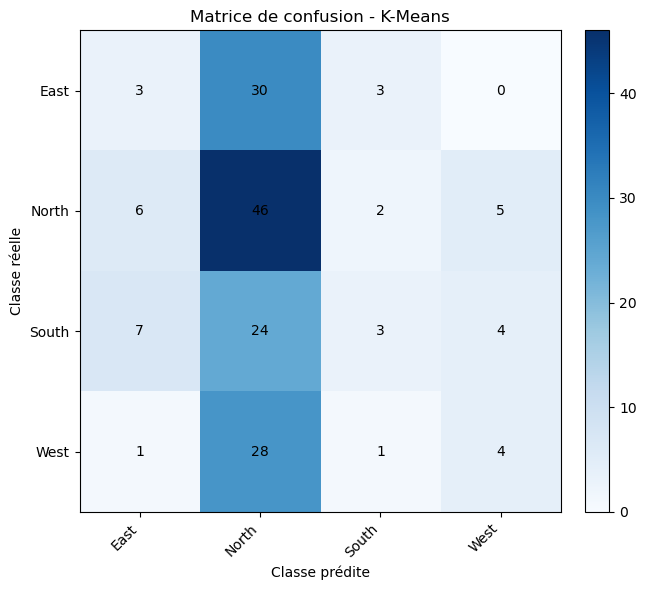

In [7]:
# Visualization: Confusion Matrix for K-Means results
import matplotlib.pyplot as plt

cm = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1, 2, 3])
labels = target_names

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Matrice de confusion - K-Means')
ax.set_xlabel('Classe prédite')
ax.set_ylabel('Classe réelle')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Applying data augmentation...


✓ Augmented dataset: 835 samples (from 167)
✓ PCA: 68 → 25 dimensions

SVM WITH DATA AUGMENTATION (BEST RESULTS)


Fold 1/5: 95.8% | Time/image: 1.8050ms | Best params: {'C': 10, 'gamma': 0.01}


Fold 2/5: 95.2% | Time/image: 1.8036ms | Best params: {'C': 10, 'gamma': 0.1}


Fold 3/5: 94.0% | Time/image: 1.9274ms | Best params: {'C': 10, 'gamma': 0.01}


Fold 4/5: 91.0% | Time/image: 2.2480ms | Best params: {'C': 100, 'gamma': 0.01}


Fold 5/5: 92.2% | Time/image: 2.0287ms | Best params: {'C': 10, 'gamma': 0.1}

SVM AUGMENTED RESULTS: 93.7% ± 1.8%
Mean time per image: 1.9625 ms

Per-Class:
  East  :  92.2% ± 4.8%
  North :  98.3% ± 1.5%
  South :  90.0% ± 6.1%
  West  :  91.2% ± 4.2%

SVM Augmented Classification Report:
              precision    recall  f1-score   support

        East      0.949     0.922     0.935       180
       North      0.915     0.983     0.948       295
       South      0.945     0.900     0.922       190
        West      0.957     0.912     0.934       170

    accuracy                          0.937       835
   macro avg      0.941     0.929     0.935       835
weighted avg      0.937     0.937     0.936       835



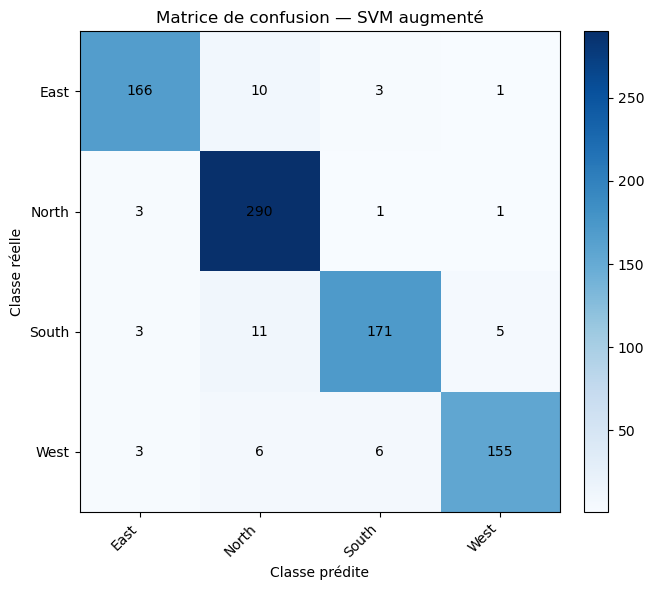

In [8]:
# Improved version with PCA, hyperparameter tuning, and data augmentation
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import time

# Data augmentation for small dataset
def augment_image(image):
    """Simple augmentations: flip, rotate, brightness"""
    augmented = []
    augmented.append(image)  # original

    # Horizontal flip
    augmented.append(cv2.flip(image, 1))

    # Vertical flip
    augmented.append(cv2.flip(image, 0))

    # Brightness variations
    for alpha in [0.8, 1.2]:
        adjusted = cv2.convertScaleAbs(image, alpha=alpha, beta=0)
        augmented.append(adjusted)

    return augmented

print("Applying data augmentation...")
X_augmented = []
y_augmented = []
crops_augmented = []  # crops augmentes alignes sur X_augmented (chronometrage)

for direction_id, images in dataset.items():
    for img_data in images:
        aug_images = augment_image(img_data['cropped'])
        for aug_img in aug_images:
            y_mask, y_img = extractor.create_yellow_mask(aug_img)
            b_mask, b_img = extractor.create_black_mask(aug_img)

            y_features = extractor.extract_stripe_features(y_mask, y_img)
            b_features = extractor.extract_stripe_features(b_mask, b_img)
            vertical_features = extractor.extract_vertical_stripe_features(y_mask, b_mask)

            features = np.concatenate([y_features, b_features, vertical_features])
            X_augmented.append(features)
            y_augmented.append(direction_id)
            crops_augmented.append(aug_img)

X_augmented = np.array(X_augmented, dtype=np.float64)
y_augmented = np.array(y_augmented, dtype=np.int32)

scaler_aug = StandardScaler()
X_augmented = scaler_aug.fit_transform(X_augmented)

print(f"✓ Augmented dataset: {X_augmented.shape[0]} samples (from {X_all.shape[0]})")

# Add PCA for dimensionality reduction
pca_aug = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_aug_pca = pca_aug.fit_transform(X_augmented)

print(f"✓ PCA: {X_augmented.shape[1]} → {X_aug_pca.shape[1]} dimensions")


def extract_features_from_crop(crop):
    """Extrait le vecteur de descripteurs d'un crop (masques jaune/noir)."""
    y_mask, y_img = extractor.create_yellow_mask(crop)
    b_mask, b_img = extractor.create_black_mask(crop)
    y_features = extractor.extract_stripe_features(y_mask, y_img)
    b_features = extractor.extract_stripe_features(b_mask, b_img)
    vertical_features = extractor.extract_vertical_stripe_features(y_mask, b_mask)
    return np.concatenate([y_features, b_features, vertical_features])


# Supervised SVM with augmented data
print("\n" + "="*70)
print("SVM WITH DATA AUGMENTATION (BEST RESULTS)")
print("="*70)

skf_aug = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
svm_aug_fold_accs = []
svm_aug_fold_time_per_image = []
svm_aug_class_accs = {i: [] for i in range(4)}
svm_aug_all_y_true = []
svm_aug_all_y_pred = []

param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1]}
svm_grid_aug = GridSearchCV(SVC(kernel='rbf', random_state=RANDOM_STATE), param_grid, cv=3, scoring='accuracy')

for fold, (train_idx, test_idx) in enumerate(skf_aug.split(X_aug_pca, y_augmented)):
    X_train, X_test = X_aug_pca[train_idx], X_aug_pca[test_idx]
    y_train, y_test = y_augmented[train_idx], y_augmented[test_idx]

    svm_grid_aug.fit(X_train, y_train)
    y_pred_svm_aug = svm_grid_aug.predict(X_test)

    # Temps de traitement d'une nouvelle image test : pipeline complet
    # crop -> extraction descripteurs -> normalisation -> PCA -> prediction SVM.
    crops_test = [crops_augmented[i] for i in test_idx]
    per_image_times = []
    for crop in crops_test:
        t0 = time.perf_counter()
        feat = extract_features_from_crop(crop)
        feat_s = scaler_aug.transform(feat.reshape(1, -1))
        feat_pca = pca_aug.transform(feat_s)
        svm_grid_aug.predict(feat_pca)
        per_image_times.append(time.perf_counter() - t0)
    time_per_image = np.mean(per_image_times)

    acc_svm_aug = accuracy_score(y_test, y_pred_svm_aug)
    svm_aug_fold_accs.append(acc_svm_aug)
    svm_aug_fold_time_per_image.append(time_per_image)

    svm_aug_all_y_true.extend(y_test)
    svm_aug_all_y_pred.extend(y_pred_svm_aug)

    for class_id in range(4):
        mask = y_test == class_id
        if np.sum(mask) > 0:
            class_acc = accuracy_score(y_test[mask], y_pred_svm_aug[mask])
            svm_aug_class_accs[class_id].append(class_acc)

    print(f"Fold {fold+1}/{CV_FOLDS}: {acc_svm_aug*100:.1f}% | Time/image: {time_per_image*1000:.4f}ms | Best params: {svm_grid_aug.best_params_}")

svm_aug_mean_acc = np.mean(svm_aug_fold_accs)
svm_aug_std_acc = np.std(svm_aug_fold_accs)
svm_aug_mean_time_per_image = np.mean(svm_aug_fold_time_per_image)

print(f"\n{'='*70}")
print(f"SVM AUGMENTED RESULTS: {svm_aug_mean_acc*100:.1f}% ± {svm_aug_std_acc*100:.1f}%")
print(f"Mean time per image: {svm_aug_mean_time_per_image*1000:.4f} ms")
print(f"{'='*70}")
print(f"\nPer-Class:")
for class_id in range(4):
    if svm_aug_class_accs[class_id]:
        m = np.mean(svm_aug_class_accs[class_id])
        s = np.std(svm_aug_class_accs[class_id])
        print(f"  {['East', 'North', 'South', 'West'][class_id]:6s}: {m*100:5.1f}% ± {s*100:.1f}%")

print(f"\nSVM Augmented Classification Report:")
print(classification_report(svm_aug_all_y_true, svm_aug_all_y_pred, target_names=target_names, digits=3))

import matplotlib.pyplot as plt

cm = confusion_matrix(svm_aug_all_y_true, svm_aug_all_y_pred, labels=[0, 1, 2, 3])
labels = target_names

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Matrice de confusion — SVM augmenté')
ax.set_xlabel('Classe prédite')
ax.set_ylabel('Classe réelle')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()